In [19]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import os
print(os.listdir('/content/drive/MyDrive'))

['dataset', 'Getting started.pdf', '1585715469456-70f0d279-e327-45ff-af90-349d74a6e89a_compress53.jpg', 'FB_IMG_1679571687333.jpg', 'FB_IMG_1679571788732.jpg', 'A,B-,B,B+,C+ what is my GPA class.gsheet', 'IMG_20240630_163425.jpg', 'Final Gantt Chart.xlsm', 'Final Gantt Chart.gsheet', '11190_MIS.pdf', 'Privacy Practices of LBS .gsheet', 'My songs', 'Colab Notebooks', 'Untitled Diagram (1).drawio', 'TOC.drawio.png', 'Untitled presentation (1).gslides', 'Contact Information.gform', 'Report (1).gdoc', 'Internship application_3 24 2025 (1)', 'Internship application_3 24 2025', 'Untitled presentation.gslides', 'Blue Orange and White Simple Modern Minimalist Circle Travel Agency Presentation.gslides', 'IMG-20250430-WA0026.jpg', 'Sandun_Lakshan_CV (1).pdf', 'Software development proposal.gdoc', 'Google AI Studio', 'Sandun Lakshan__CV..pdf', 'Payment_Slip (1).jpg', 'Payment_Slip.jpg', 'Copy of Research Paper Presentation-20250630_184433-Meeting Recording.mp4', 'Sandun_Lakshan_CV.pdf', 'Sandun L

In [22]:
folder_path = "/content/drive/MyDrive/dataset"

In [23]:
import os

files = os.listdir(folder_path)
print(files)

['Healthy_plant', 'With_Whitefly', 'train', 'val']


In [9]:
import tensorflow as tf

In [24]:
import tensorflow as tf

dataset_dir = "/content/drive/MyDrive/dataset"

BATCH_SIZE = 32
IMG_SIZE = (256,256)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,   # 20% validation
    subset="training",
    seed=123,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

Found 772 files belonging to 2 classes.
Using 618 files for training.
Found 772 files belonging to 2 classes.
Using 154 files for validation.


In [49]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    shuffle=True,
    batch_size=32,
    image_size=(256,256)
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    shuffle=True,
    batch_size=32,
    image_size=(256,256)
)

# Save class names here
class_names = train_dataset.class_names

# Optional performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

Found 772 files belonging to 2 classes.
Using 618 files for training.
Found 772 files belonging to 2 classes.
Using 154 files for validation.


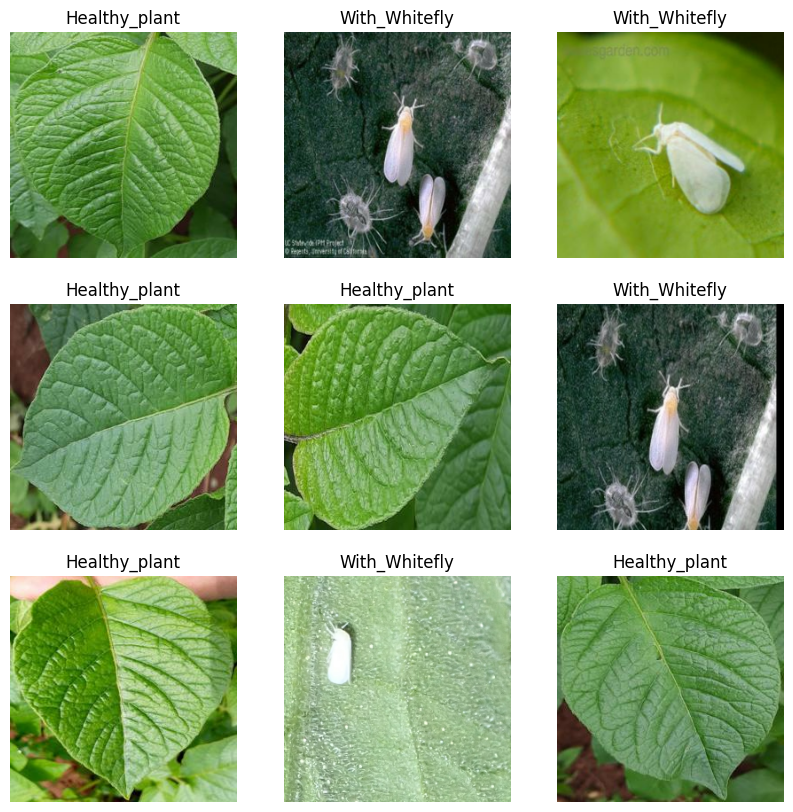

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [43]:
class_names

['Healthy_plant', 'With_Whitefly']

In [44]:
preprocess_input = tf.keras.applications.efficientnet.preprocess_input

In [51]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

In [57]:
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.EfficientNetB4(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet',
)

In [58]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 8, 8, 1792)


In [59]:
base_model.trainable = False

In [60]:
base_model.summary()

Model: "efficientnetb4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 256, 256,  │          0 │ input_layer_5[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_3     │ (None, 256, 256,  │          7 │ rescaling_6[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 256, 256,  │          0 │ normalization_3[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 257, 257,  │          0 │ rescaling_7[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 128, 128,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 128, 128,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 128, 128,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 128, 128,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 128, 128,  │      1,152 │ block1a_se_excit

 Total params: 17,673,823 (67.42 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 17,673,823 (67.42 MB)

In [61]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1792)


In [62]:
prediction_layer = tf.keras.layers.Dense(len(class_names), activation='sigmoid')
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 2)


In [63]:
inputs = tf.keras.Input(shape=(256, 256, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

In [36]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 8, 8, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         3,586 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,677,409 (67.43 MB)

 Trainable params: 3,586 (14.01 KB)

 Non-trainable params: 17,673,823 (67.42 MB)

In [64]:
len(model.trainable_variables)

2

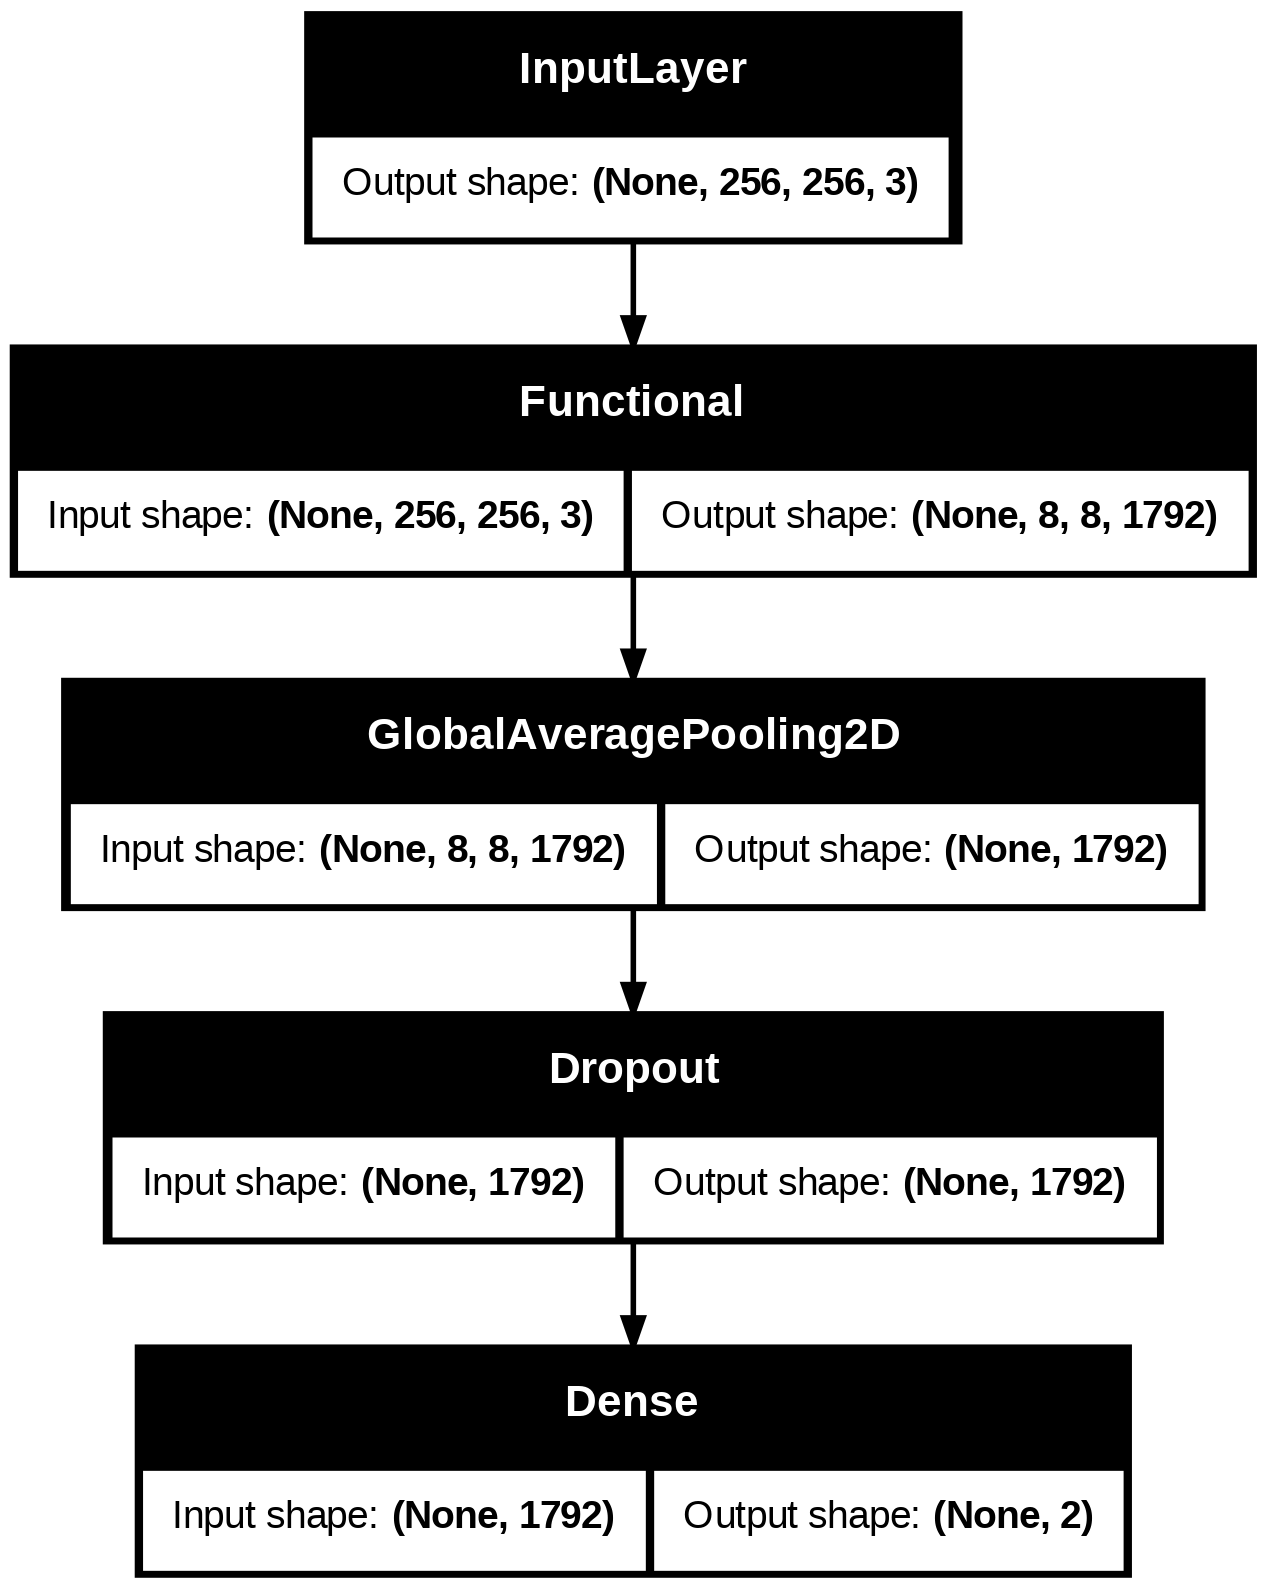

In [65]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [66]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')])

In [67]:
initial_epochs = 10

loss0, accuracy0 = model.evaluate(validation_dataset)

5/5 ━━━━━━━━━━━━━━━━━━━━ 54s 5s/step - accuracy: 0.8182 - loss: 0.5161


In [68]:
print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

initial loss: 0.52
initial accuracy: 0.82


In [69]:
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 154s 6s/step - accuracy: 0.9676 - loss: 0.1788 - val_accuracy: 1.0000 - val_loss: 0.0387
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.9919 - loss: 0.0364 - val_accuracy: 1.0000 - val_loss: 0.0202
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.9951 - loss: 0.0222 - val_accuracy: 1.0000 - val_loss: 0.0160
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.9984 - loss: 0.0169 - val_accuracy: 1.0000 - val_loss: 0.0156
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.9984 - loss: 0.0145 - val_accuracy: 1.0000 - val_loss: 0.0125
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.9984 - loss: 0.0117 - val_accuracy: 1.0000 - val_loss: 0.0122
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - accuracy: 0.9984 - loss: 0.0114 - val_accuracy: 0.9935 - val_loss: 0.0130
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - accuracy: 1.0000 - loss: 0.0083 - val_accuracy: 1.0

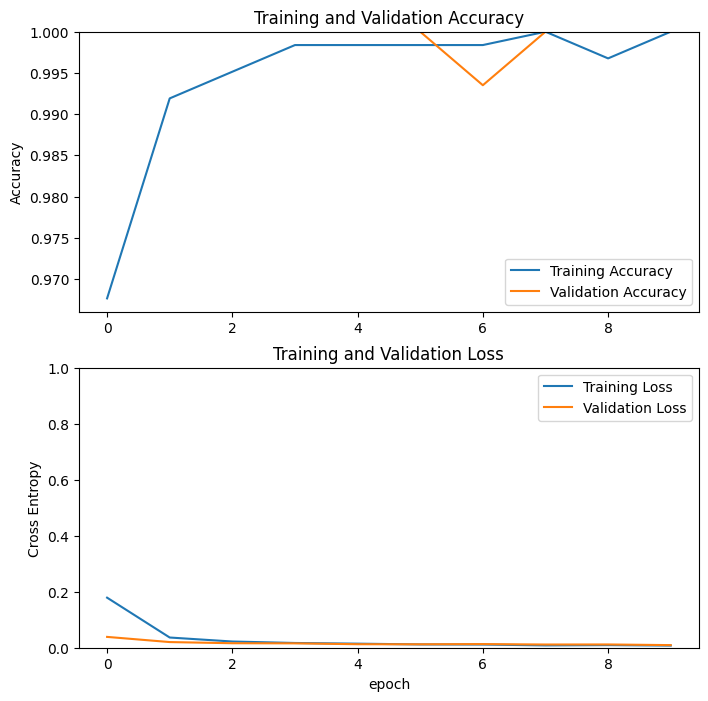

In [70]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [71]:
base_model.trainable = True

In [72]:
print("Number of layers in the base model: ", len(base_model.layers))
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  475


In [73]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')])

In [74]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 8, 8, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         3,586 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,677,409 (67.43 MB)

 Trainable params: 17,465,442 (66.63 MB)

 Non-trainable params: 211,967 (828.00 KB)

In [75]:
len(model.trainable_variables)

333

In [76]:
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=len(history.epoch),
                         validation_data=validation_dataset)

Epoch 11/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 228s 5s/step - accuracy: 0.9773 - loss: 0.0444 - val_accuracy: 0.9935 - val_loss: 0.0125
Epoch 12/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 355ms/step - accuracy: 0.9790 - loss: 0.0560 - val_accuracy: 0.9610 - val_loss: 0.8943
Epoch 13/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 345ms/step - accuracy: 0.9919 - loss: 0.0330 - val_accuracy: 0.9740 - val_loss: 0.5494
Epoch 14/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 362ms/step - accuracy: 0.9887 - loss: 0.0191 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 15/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 357ms/step - accuracy: 0.9984 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0039
Epoch 16/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 369ms/step - accuracy: 1.0000 - loss: 4.2848e-04 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 17/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 349ms/step - accuracy: 1.0000 - loss: 1.0678e-04 - val_accuracy: 1.0000 - val_loss: 9.5504e-04
Epoch 18/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 361ms/step - accuracy: 1.0000 - loss: 7.2828

In [77]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

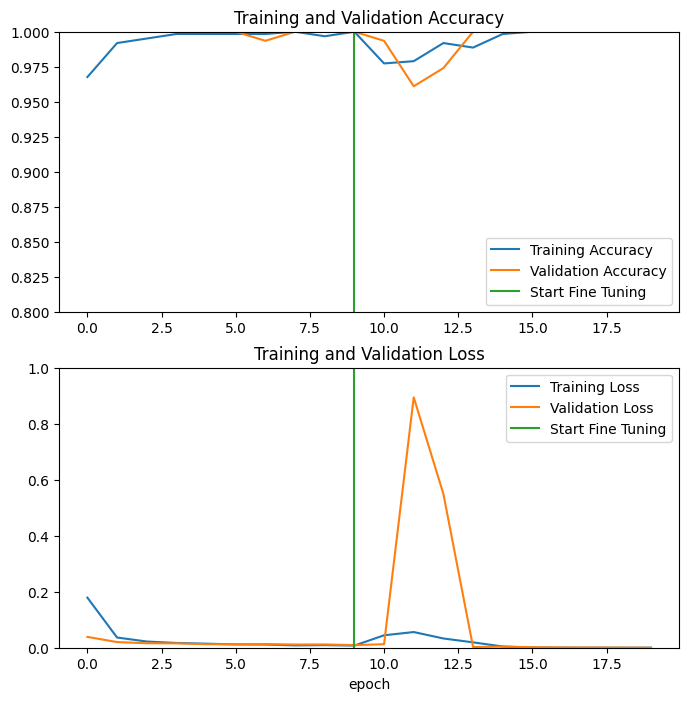

In [78]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [82]:
loss, accuracy = model.evaluate(validation_dataset)
print('Validation accuracy:', accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 1.0000 - loss: 7.8214e-05
Validation accuracy: 1.0


Predictions:
 [0 1 0 0 1 1 0 0 1 1 0 1 1 0 1 0 1 1 0 1 1 1 0 1 0 1 0 1 0 1 1 1]
Labels:
 [0 1 0 0 1 1 0 0 1 1 0 1 1 0 1 0 1 1 0 1 1 1 0 1 0 1 0 1 0 1 1 1]


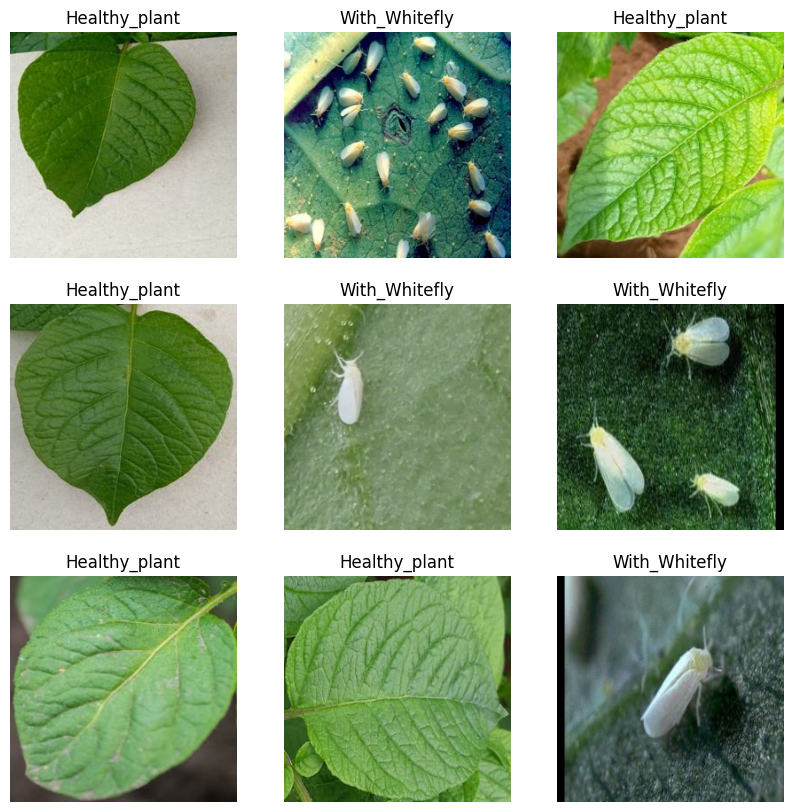

In [85]:
image_batch, label_batch = validation_dataset.as_numpy_iterator().next()

predictions = model.predict_on_batch(image_batch)
predictions = tf.argmax(predictions, axis=1)

print('Predictions:\n', predictions.numpy())
print('Labels:\n', label_batch)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].astype("uint8"))
    plt.title(class_names[predictions[i]])
    plt.axis("off")

In [87]:
model.save("plant_Pest_recog_model_php.keras")

In [88]:
model.save("/content/drive/MyDrive/plant_pest_recog_model_php.keras")

In [89]:
model.evaluate(validation_dataset)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 1.0000 - loss: 7.8214e-05


[7.821357576176524e-05, 1.0]

In [90]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in validation_dataset:
    preds = model.predict(images)
    preds = tf.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.numpy())

cm = confusion_matrix(y_true, y_pred)
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
[[75  0]
 [ 0 79]]


In [91]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

               precision    recall  f1-score   support

Healthy_plant       1.00      1.00      1.00        75
With_Whitefly       1.00      1.00      1.00        79

     accuracy                           1.00       154
    macro avg       1.00      1.00      1.00       154
 weighted avg       1.00      1.00      1.00       154



In [92]:
model.save("pest_model.h5")

In [93]:
model = tf.keras.models.load_model("pest_model.h5")

In [101]:
import os
print(os.listdir("/content/drive/MyDrive/dataset"))

['Healthy_plant', 'With_Whitefly', 'tes3.JPG', 'Test1.JPG', 'test2.jpg']


In [102]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file == "test1.jpg":
            print("FOUND:", os.path.join(root, file))

In [111]:
img_path = "/content/drive/MyDrive/dataset/Test1.JPG"

In [113]:
import tensorflow as tf
import numpy as np

# 👉 correct image path (ඔයාගේ real path එක දාන්න)
img_path = "/content/drive/MyDrive/dataset/test2.jpg"

# Load image
img = tf.keras.utils.load_img(
    img_path,
    target_size=(256, 256)
)

# Convert to array
img = tf.keras.utils.img_to_array(img)

# Add batch dimension
img = tf.expand_dims(img, 0)

# Prediction
pred = model.predict(img)

# Get class name
pred_class = class_names[np.argmax(pred[0])]

# Output
print("Prediction:", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
Prediction: With_Whitefly
